In [20]:
import xarray as xr
import yaml
import os

In [21]:
fcst_yaml_path = "forecast.yaml"

In [22]:
with open(fcst_yaml_path, "r") as f:
    try:
        fcst_params = yaml.safe_load(f)
    except yaml.YAMLError as exc:
        print(exc)
        raise
output_folder = fcst_params["OUTPUT"]["folder"]
save_crps_only = fcst_params["OUTPUT"]["save_crps_only"]
truth_input_folder = fcst_params["INPUT"]["truth_folder"]

In [23]:
files = os.listdir(output_folder)

In [24]:
file_path = files[10] # Pick a random file

fcst = xr.load_dataset(f"{output_folder}/{file_path}")
fcst

<xarray.Dataset>
Dimensions:          (y: 99, x: 99, member: 51, time: 1, valid_time: 1)
Coordinates:
  * y                (y) float32 1.505e+05 1.515e+05 ... 2.475e+05 2.485e+05
  * x                (x) float32 4.505e+05 4.515e+05 ... 5.475e+05 5.485e+05
  * member           (member) int32 1 2 3 4 5 6 7 8 ... 44 45 46 47 48 49 50 51
  * time             (time) datetime64[ns] 2023-07-01
Dimensions without coordinates: valid_time
Data variables:
    fcst_valid_time  (time, valid_time) datetime64[ns] 2023-07-02T06:00:00
    precipitation    (time, member, valid_time, y, x) float32 0.003248 ... 0....
    crps             (time, valid_time, y, x) float32 0.01905 ... 0.02113
Attributes:
    description:  GAN 24-hour rainfall ensemble members in the ICPAC region.

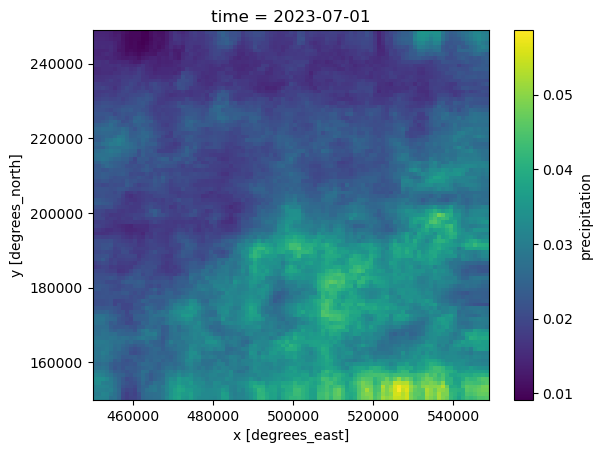

In [25]:
#plot precip if present
if not save_crps_only:
    fcst.precipitation.median('member').isel(valid_time=0, time=0).plot()

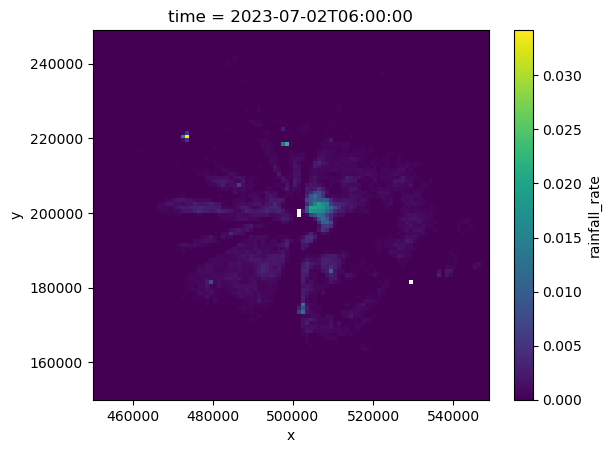

In [26]:
#plot truth
time = fcst.fcst_valid_time[0]
truth = xr.load_dataset(f"{truth_input_folder}/{str(time.dt.year.values[0])}/{time.dt.strftime('%Y%m%d').values[0]}_06.nc")
truth.rainfall_rate.isel(time=0).plot()


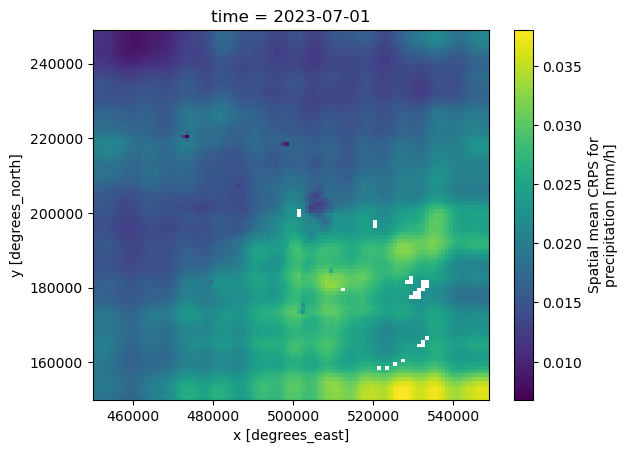

In [27]:
#plot crps
fcst.crps.isel(valid_time=0, time=0).plot()

In [28]:
#Plot CRPS
fcsts = xr.open_mfdataset(f"{output_folder}/*.nc", combine="by_coords")
fcsts = fcsts.where(fcsts.crps < 1e36) #remove missing values

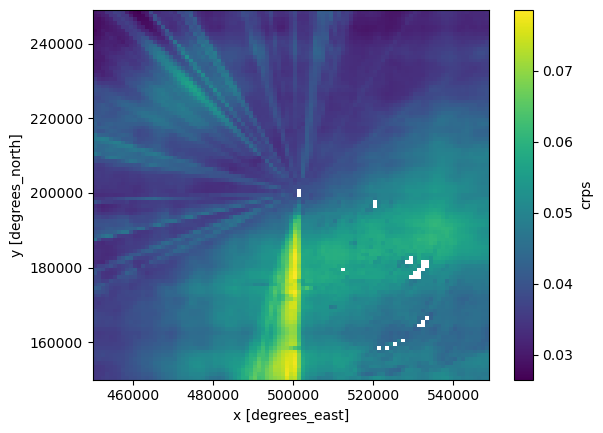

In [29]:
fcsts.crps.mean('time').plot()

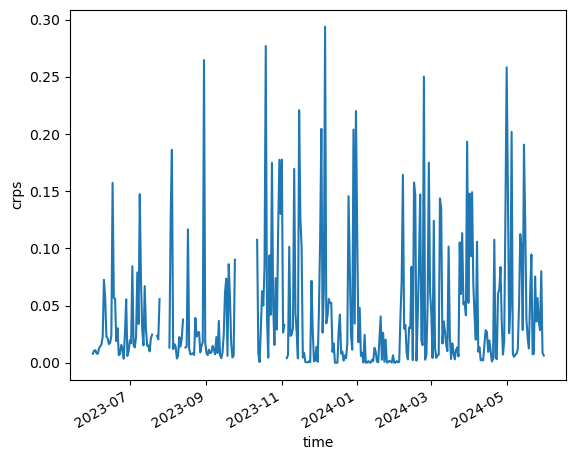

In [30]:
fcsts.crps.mean(('x','y')).plot()